# Data Preperation

In [299]:
# Make sure to pip install openpyxl before reading excel files

In [300]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## Orders

In [301]:
DATA_PATH = 'Muesli Project raw data.xlsx'
orders = pd.read_excel(DATA_PATH, sheet_name='Orders')

# rename columns in the dateset 
# get columns names from the first row 
col_names = list(orders.iloc[0])

# assign the columns names the right name
orders.columns = col_names
orders = orders[1:]

orders.head(5)

,Index,Order ID,Order Date,Ship Mode,Customer ID,Customer Name,Origin Channel,Country/Region,City,State,Postal Code,Region,Category,Sub-Category,Product ID,Sales,Quantity,Discount,Profit
1,27,CA-2019-121755,2019-01-16 00:00:00,Second Class,EH-13945,Eric Hoffmann,Email,United States,Los Angeles,California,90049,West,Special Projects Muesil,Gluten Free,TEC-AC-10003027,90.57,3,0,11.77
2,45,CA-2019-118255,2019-03-11 00:00:00,First Class,ON-18715,Odella Nelson,Sales,United States,Eagan,Minnesota,55122,Central,Special Projects Muesil,Gluten Free,TEC-AC-10000171,45.98,2,0,19.77
3,48,CA-2019-169194,2019-06-20 00:00:00,Standard Class,LH-16900,Lena Hernandez,Email,United States,Dover,Delaware,19901,East,Special Projects Muesil,Gluten Free,TEC-AC-10002167,45,3,0,4.95
4,60,CA-2019-111682,2019-06-17 00:00:00,First Class,TB-21055,Ted Butterfield,Email,United States,Troy,New York,12180,East,Special Projects Muesil,Gluten Free,TEC-AC-10002167,30,2,0,3.30
5,63,CA-2018-135545,2018-11-24 00:00:00,Standard Class,KM-16720,Kunst Miller,Email,United States,Los Angeles,California,90004,West,Special Projects Muesil,Gluten Free,TEC-AC-10004633,13.98,2,0,6.15


In [302]:
orders.shape

(9994, 19)

In [303]:
# Droping Excel Index Column 
orders.drop(columns='Index', inplace=True)

In [304]:
orders.duplicated().sum()

1

In [305]:
orders.isna().sum() # We have 11 NA's in orders in Postal Code. We do not need this column for now so I will just ignore it for now.

Order ID           0
Order Date         0
Ship Mode          0
Customer ID        0
Customer Name      0
Origin Channel     0
Country/Region     0
City               0
State              0
Postal Code       11
Region             0
Category           0
Sub-Category       0
Product ID         0
Sales              0
Quantity           0
Discount           0
Profit             0
dtype: int64

All features in the dataset are objects. <br> Data types should be reformated.

In [306]:
# TODO: Convert dates to date data-type 
orders['Order Date'] = orders['Order Date'].astype('datetime64[ns]')

In [307]:
# TODO: Convert numbers in sales, quantity discount and profit 
orders['Sales'] = orders['Sales'].astype(float)
orders['Quantity'] = orders['Quantity'].astype(int)
orders['Discount'] = orders['Discount'].astype(float)
orders['Profit'] = orders['Profit'].astype(float)

In [308]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 1 to 9994
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Order ID        9994 non-null   object        
 1   Order Date      9994 non-null   datetime64[ns]
 2   Ship Mode       9994 non-null   object        
 3   Customer ID     9994 non-null   object        
 4   Customer Name   9994 non-null   object        
 5   Origin Channel  9994 non-null   object        
 6   Country/Region  9994 non-null   object        
 7   City            9994 non-null   object        
 8   State           9994 non-null   object        
 9   Postal Code     9983 non-null   object        
 10  Region          9994 non-null   object        
 11  Category        9994 non-null   object        
 12  Sub-Category    9994 non-null   object        
 13  Product ID      9994 non-null   object        
 14  Sales           9994 non-null   float64       
 15  Quan

In [309]:
orders.drop_duplicates(inplace=True)
orders.duplicated().value_counts()

False    9993
Name: count, dtype: int64

In [310]:
orders.describe()

,Order Date,Sales,Quantity,Discount,Profit
count,9993,"9,993.00","9,993.00","9,993.00","9,993.00"
mean,2019-04-30 19:27:38.961273088,229.85,3.79,0.16,28.66
min,2017-01-03 00:00:00,0.44,1.00,0.00,"-6,599.98"
25%,2018-05-23 00:00:00,17.28,2.00,0.00,1.73
50%,2019-06-26 00:00:00,54.48,3.00,0.20,8.67
75%,2020-05-14 00:00:00,209.94,5.00,0.20,29.36
max,2020-12-30 00:00:00,"22,638.48",14.00,0.80,"8,399.98"
std,NaN,623.28,2.23,0.21,234.27


## Campagin data

In [311]:
campaign_data = pd.read_excel(DATA_PATH, sheet_name='Campaign Data')

In [312]:
campaign_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 333 entries, 0 to 332
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Order ID           333 non-null    object        
 1   Arrival Scan Date  333 non-null    datetime64[ns]
 2   Customer Name      333 non-null    object        
dtypes: datetime64[ns](1), object(2)
memory usage: 7.9+ KB


We have 333 customers who scaned the orders when arrived.

In [313]:
campaign_data.duplicated().sum()

0

In [314]:
campaign_data.isna().sum()

Order ID             0
Arrival Scan Date    0
Customer Name        0
dtype: int64

## Order process data

In [315]:
order_process = pd.read_excel(DATA_PATH, sheet_name='Order Process Data')
order_process.head(5)

,Row ID,Order ID,Order Date,On Truck Scan Date,Ship Mode
0,3074,CA-2019-125206,2019-01-03,2019-01-07,Express
1,4919,CA-2019-160304,2019-01-02,2019-01-09,Standard Processing
2,4920,CA-2019-160304,2019-01-02,2019-01-09,Standard Processing
3,8604,US-2019-116365,2019-01-03,2019-01-09,Standard Processing
4,8605,US-2019-116365,2019-01-03,2019-01-09,Standard Processing


In [316]:
order_process.duplicated().value_counts()

False    5899
Name: count, dtype: int64

In [317]:
order_process.isna().sum()

Row ID                0
Order ID              0
Order Date            0
On Truck Scan Date    0
Ship Mode             0
dtype: int64

In [318]:
order_process.describe()

,Row ID,Order Date,On Truck Scan Date
count,"5,899.00",5899,5899
mean,"5,022.43",2020-02-29 02:22:48.231903744,2020-03-06 05:16:21.929140480
min,1.00,2019-01-02 00:00:00,2019-01-07 00:00:00
25%,"2,485.50",2019-09-11 00:00:00,2019-09-18 00:00:00
50%,"5,091.00",2020-03-16 00:00:00,2020-03-20 00:00:00
75%,"7,460.00",2020-09-13 12:00:00,2020-09-18 00:00:00
max,"9,994.00",2020-12-30 00:00:00,2021-01-06 00:00:00
std,"2,878.46",NaN,NaN


## Intern Data

In [319]:
intern_data = pd.read_excel(DATA_PATH, sheet_name='InternData Study')
intern_data.head(5)
intern_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290 entries, 0 to 289
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Order ID            290 non-null    object        
 1   Ready to Ship Date  290 non-null    datetime64[ns]
 2   Pickup Date         290 non-null    datetime64[ns]
dtypes: datetime64[ns](2), object(1)
memory usage: 6.9+ KB


In the intern dataset there is 86 duplicated values.
We need here to add other indicators and understand why is there so many duplicts and improve the data quality for each scan.

In [320]:
print(intern_data['Order ID'].duplicated().value_counts(), '\n')
print(intern_data['Ready to Ship Date'].duplicated().value_counts()) # make sense because on the same day there is many orders
intern_data['Pickup Date'].duplicated().value_counts() # make sense because on the same day there is pickups

Order ID
False    204
True      86
Name: count, dtype: int64 

Ready to Ship Date
True     247
False     43
Name: count, dtype: int64


Pickup Date
True     260
False     30
Name: count, dtype: int64

In [321]:
intern_data.drop_duplicates(inplace=True)

In [322]:
intern_data.isna().sum()

Order ID              0
Ready to Ship Date    0
Pickup Date           0
dtype: int64

In [323]:
intern_data.describe()

,Ready to Ship Date,Pickup Date
count,204,204
mean,2020-07-07 01:03:31.764705792,2020-07-08 14:49:24.705882368
min,2019-09-02 00:00:00,2019-09-03 00:00:00
25%,2019-09-24 00:00:00,2019-09-25 00:00:00
50%,2020-11-12 00:00:00,2020-11-13 00:00:00
75%,2020-11-23 00:00:00,2020-11-25 00:00:00
max,2020-12-07 00:00:00,2020-12-09 00:00:00


## Processing Time

In [ ]:
# in the warehause -> on truck scan - order date 
order_process.info()
order_process['total_time_in_warehause'] = order_process['On Truck Scan Date'] - order_process['Order Date']

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5899 entries, 0 to 5898
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Row ID              5899 non-null   int64         
 1   Order ID            5899 non-null   object        
 2   Order Date          5899 non-null   datetime64[ns]
 3   On Truck Scan Date  5899 non-null   datetime64[ns]
 4   Ship Mode           5899 non-null   object        
dtypes: datetime64[ns](2), int64(1), object(2)
memory usage: 230.6+ KB


In [325]:
print(intern_data.head())
order_process.head()

         Order ID Ready to Ship Date Pickup Date
0  CA-2019-116540         2019-09-02  2019-09-03
2  CA-2019-129847         2019-09-04  2019-09-04
3  CA-2019-129630         2019-09-04  2019-09-04
4  CA-2019-106278         2019-09-05  2019-09-06
5  CA-2019-158099         2019-09-05  2019-09-06


,Row ID,Order ID,Order Date,On Truck Scan Date,Ship Mode,total_time_in_wearhause
0,3074,CA-2019-125206,2019-01-03,2019-01-07,Express,4 days
1,4919,CA-2019-160304,2019-01-02,2019-01-09,Standard Processing,7 days
2,4920,CA-2019-160304,2019-01-02,2019-01-09,Standard Processing,7 days
3,8604,US-2019-116365,2019-01-03,2019-01-09,Standard Processing,6 days
4,8605,US-2019-116365,2019-01-03,2019-01-09,Standard Processing,6 days


In [326]:
processing_df = pd.merge(left=order_process, right=intern_data, how='inner' ,on='Order ID')
processing_df['processing_time'] = processing_df['Ready to Ship Date'] - processing_df['Order Date']

In [ ]:
plt.style.use('fivethirtyeight') 
pd.options.display.float_format = "{:,.2f}".format

total_warehause_hist_x = processing_df['total_time_in_warehause'].dt.days
processing_hist_x = processing_df['processing_time'].dt.days
print("Total time spend in warehouse before shipping",total_warehause_hist_x.describe(), "\n")
print("Processing Time",processing_hist_x.describe())

Total time spend in weaehouse before shipping count   418.00
mean      5.80
std       2.55
min       0.00
25%       4.00
50%       7.00
75%       8.00
max      10.00
Name: total_time_in_wearhause, dtype: float64 

Processing Time count   418.00
mean      4.16
std       1.95
min       0.00
25%       3.00
50%       5.00
75%       6.00
max       8.00
Name: processing_time, dtype: float64


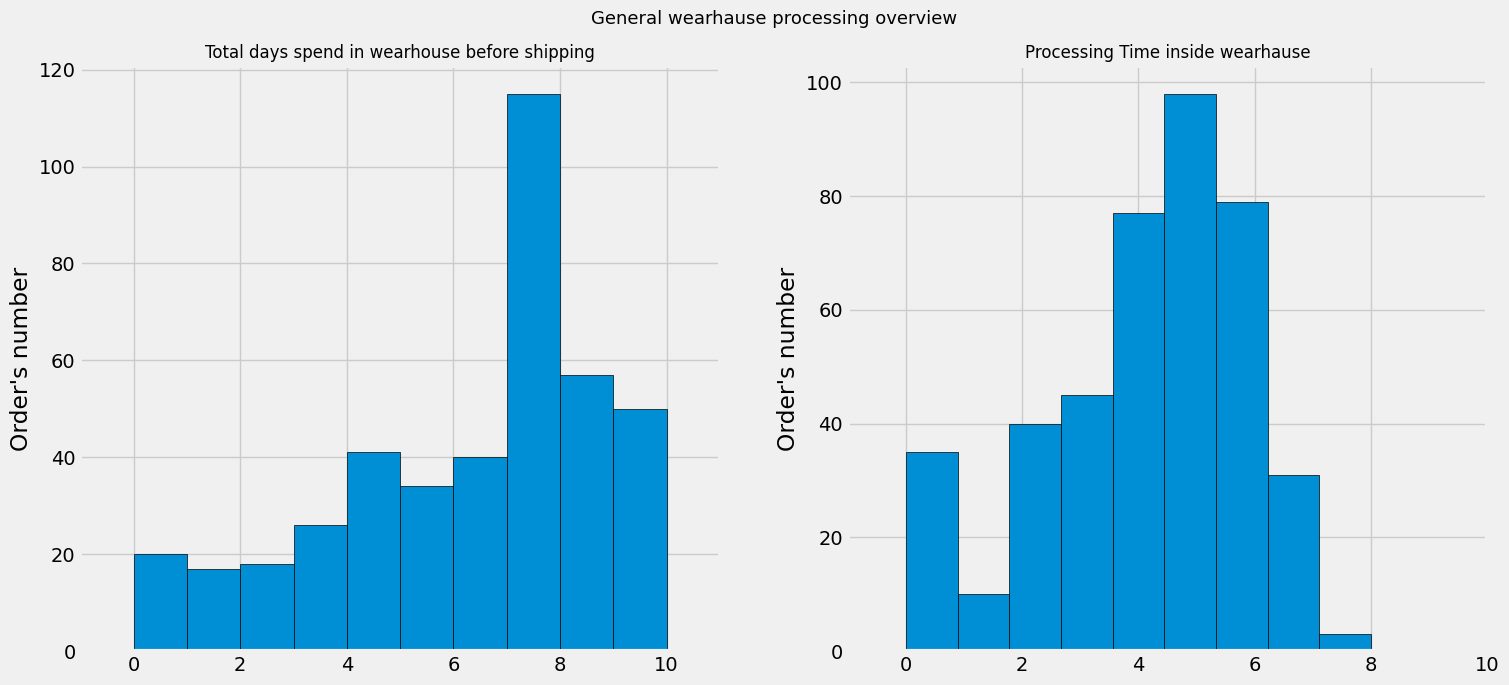

In [ ]:

fig, ax = plt.subplots(1,2, figsize=(15,7))
plt.suptitle('General warehause processing overview', fontsize=13)
fig.tight_layout()
plt.subplots_adjust(hspace = .5, wspace = .2, top = .9)

ax[0].hist(x=total_warehause_hist_x, bins=10, edgecolor='black')
ax[0].set_ylabel('Order\'s number')
ax[0].set_xlim(-1,11)
ax[0].set_title('Total days spend in warehouse before shipping', fontsize = 12)

ax[1].hist(x=processing_hist_x, bins=9, edgecolor='black')
ax[1].set_ylabel('Order\'s number')
ax[1].set_xlim(-1,10)
ax[1].set_title('Processing Time inside warehause', fontsize = 12);

In [329]:
processing_df['Ship Mode'].value_counts()

Ship Mode
Standard Processing    316
Express                102
Name: count, dtype: int64

In [ ]:
express_orders = processing_df[processing_df['Ship Mode'] == 'Express']
express_whtd = express_orders['total_time_in_warehause'].dt.days
express_pt = express_orders['processing_time'].dt.days

standard_orders = processing_df[processing_df['Ship Mode'] == 'Standard Processing']
standard_whtd = standard_orders['total_time_in_warehause'].dt.days
standard_pt = standard_orders['processing_time'].dt.days

print(express_orders['Ship Mode'].describe(),'\n')
print(standard_orders['Ship Mode'].describe())

count         102
unique          1
top       Express
freq          102
Name: Ship Mode, dtype: object 

count                     316
unique                      1
top       Standard Processing
freq                      316
Name: Ship Mode, dtype: object


Text(0.5, 1.0, 'Total Days in Wearhause before shipment (Express)')

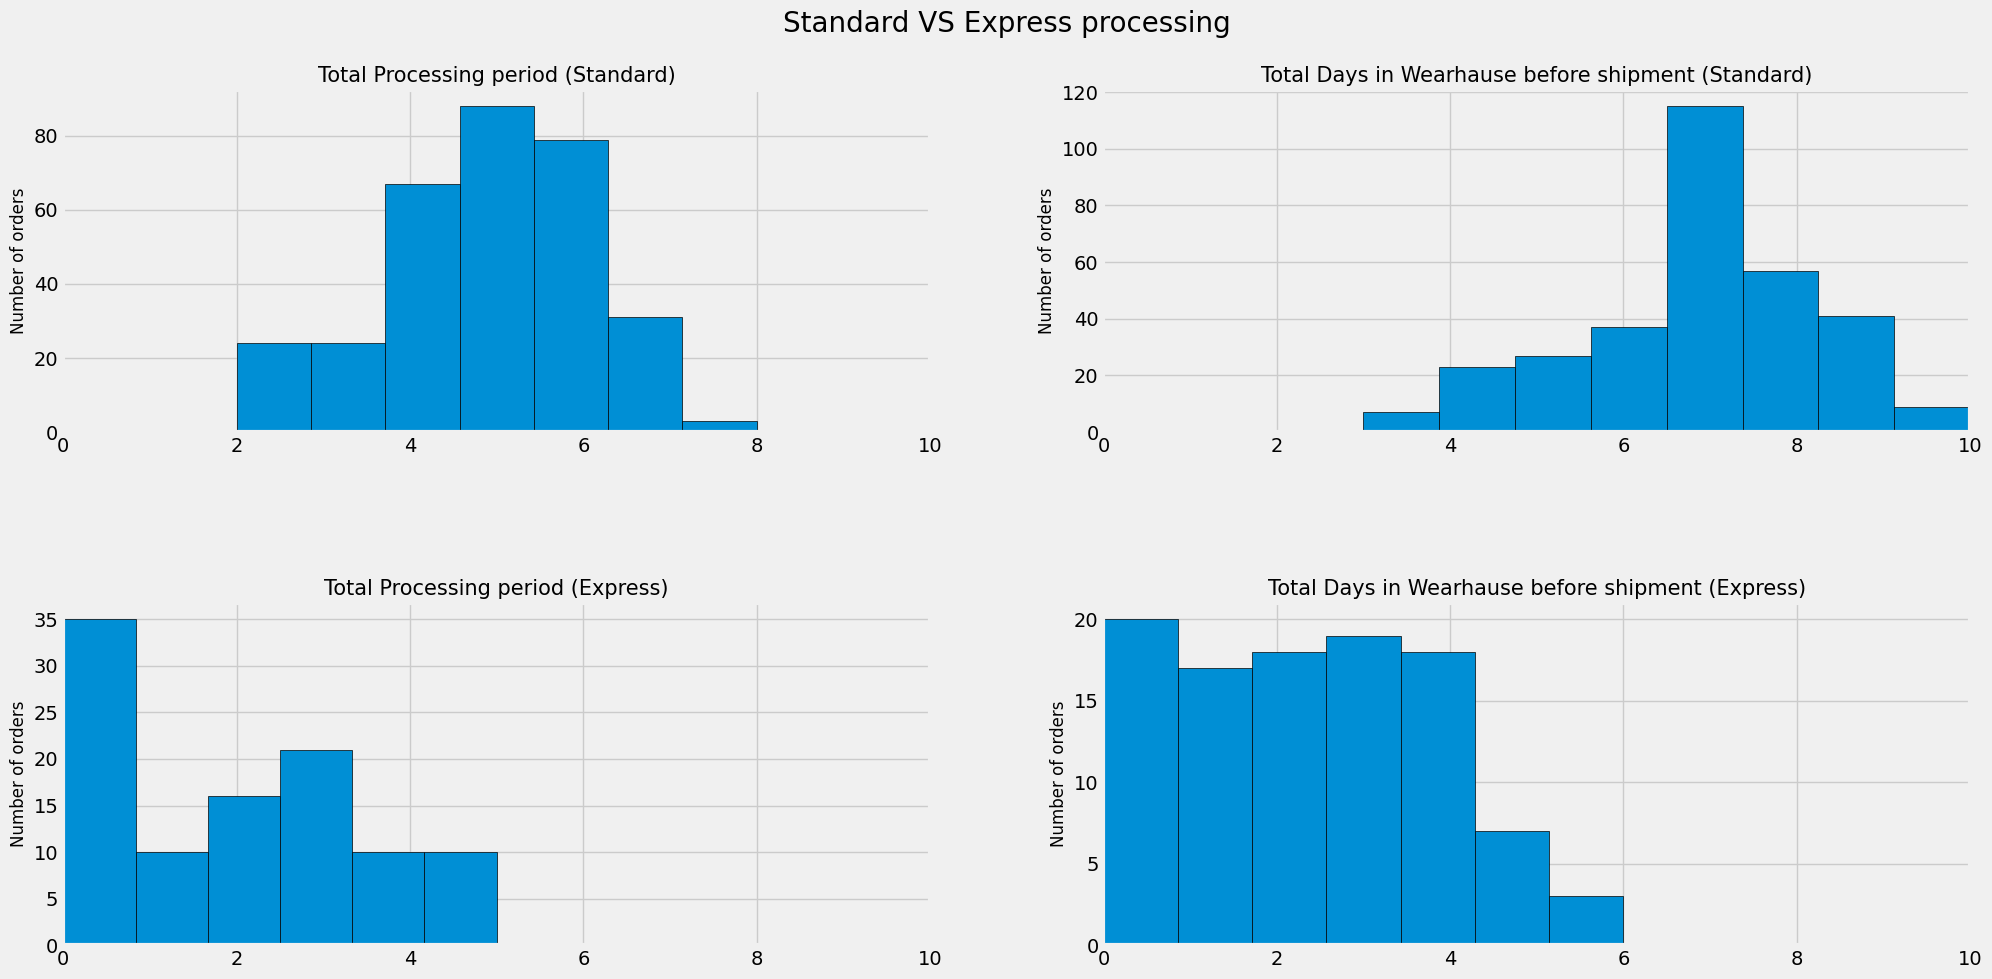

In [ ]:
fig, ax = plt.subplots(2,2, figsize=(20,10))
plt.suptitle('Standard VS Express processing', fontsize=20)
fig.tight_layout()
plt.subplots_adjust(hspace=.5, wspace=.2, top=.9)

ax[0][0].hist(x=standard_pt, bins=7, edgecolor='black')
ax[0][0].set_ylabel('Number of orders', fontsize=12)
ax[0][0].set_xlim(0,10)
ax[0][0].set_title('Total Processing period (Standard)', fontsize=15)

ax[0][1].hist(x=standard_whtd, bins=8, edgecolor='black')
ax[0][1].set_ylabel('Number of orders', fontsize=12)
ax[0][1].set_xlim(0,10)
ax[0][1].set_title('Total Days in Warehause before shipment (Standard)', fontsize=15)


ax[1][0].hist(x=express_pt, bins=6, edgecolor='black')
ax[1][0].set_ylabel('Number of orders', fontsize=12)
ax[1][0].set_xlim(0,10)
ax[1][0].set_title('Total Processing period (Express)', fontsize=15)

ax[1][1].hist(x=express_whtd, bins=7, edgecolor='black')
ax[1][1].set_ylabel('Number of orders', fontsize=12)
ax[1][1].set_xlim(0,10)
ax[1][1].set_title('Total Days in Warehause before shipment (Express)', fontsize=15)